In [1]:
# reload magic
%reload_ext autoreload
%autoreload 2


In [2]:
# imports
from pathlib import Path
import sys  

# Get my_package directory path from Notebook
parent_dir = str(Path().resolve().parents[0])

# Add to sys.path
sys.path.insert(0, parent_dir)


In [3]:
from utils.experiment_utils import get_all_experiments_info, load_best_model

device = 'cuda'
configs = get_all_experiments_info('../outputs/', False)
cfgs = [
    c for c in configs if 'mvn' in c['name']    
        and c['config']['dataset']['n_sets'] == 50_000
        and 'n_unique_sets' in c['config']['dataset']
        and c['config']['training']['num_epochs'] == 1000
        # and c['generator'] == 'DDPM'
        # and c['config']['dataset']['set_size'] == 500
]

In [4]:
import hydra
# load + prep dataset
def prepare_dataset(dataset_cfg):
    # probs = np.column_stack((np.linspace(0, 1, num_probs), 1 - np.linspace(0, 1, num_probs)))
    dataset = hydra.utils.instantiate(dataset_cfg)
    # dataset.probs = probs
    # dataset.data, _, _ = dataset.make_sets()
    return dataset

# load encoder and move to device
def load_model(cfg, path, device):
    enc = hydra.utils.instantiate(cfg['encoder'])
    gen = hydra.utils.instantiate(cfg['generator'])
    state = load_best_model(path)
    enc.load_state_dict(state['encoder_state_dict'])
    gen.load_state_dict(state['generator_state_dict'])
    enc.eval()
    gen.eval()
    enc.to(device)
    gen.to(device)
    return enc, gen


enc, gen = load_model(cfgs[0]['config'], cfgs[0]['dir'], device)


In [16]:
from tkinter import N


emb_models = {}
mm_models = {}
dist_models = {}
for cfg in cfgs:
    n_unique_sets = cfg['config']['dataset']['n_unique_sets']
    if cfg['encoder'] == 'EmbeddingEncoder':
        print("emb", n_unique_sets)
        emb_models[n_unique_sets] = load_model(cfg['config'], cfg['dir'], device)
    elif cfg['encoder'] == 'OneHotEncoder':
        print("oh", n_unique_sets)
        if cfg['model'] == 'MultiMarginalMLP':
            print("mm", n_unique_sets)
            mm_models[n_unique_sets] = load_model(cfg['config'], cfg['dir'], device)
        # oh_models[n_unique_sets] = load_model(cfg['config'], cfg['dir'], device)
    else:
        print("dist", n_unique_sets, cfg)
        dist_models[n_unique_sets] = load_model(cfg['config'], cfg['dir'], device)



dist 10000 {'name': 'mvn_coupled_exp_cf83082ec68711d5357807229ee40bc7', 'dir': '../outputs/mvn_coupled_exp_cf83082ec68711d5357807229ee40bc7', 'config': {'dataset': {'_target_': 'datasets.distribution_datasets.MultivariateNormalDistributionDataset', 'n_sets': 50000, 'set_size': '${experiment.set_size}', 'data_shape': [2], 'seed': '${seed}', 'prior_mu': [0, 5], 'prior_cov_df': 10, 'prior_cov_scale': 1, 'n_unique_sets': 10000}, 'encoder': {'_target_': 'encoder.encoders.DistributionEncoderGNN', 'in_dim': '${dataset.data_shape[0]}', 'latent_dim': '${experiment.latent_dim}', 'hidden_dim': '${experiment.hidden_dim}', 'set_size': '${experiment.set_size}', 'layers': 2, 'fc_layers': 2}, 'model': {'_target_': 'layers.MLP', 'in_dims': [2, 1, 16, 16], 'hidden_dim': 64, 'out_dim': 2, 'layers': 4}, 'coupling': {'_target_': 'types.NoneType'}, 'generator': {'_target_': 'generator.flow_matching.FlowMatchingGenerator', 'model': '${model}', 'sigma_min': 0.5}, 'optimizer': {'_target_': 'torch.optim.Adam', 

In [17]:
import copy
dataset_cfg = copy.deepcopy(cfgs[0]['config']['dataset'])
dataset_cfg['n_unique_sets'] = 50000
dataset_cfg['set_size'] = 10_000
ds = prepare_dataset(dataset_cfg)

In [ ]:
import torch
import numpy as np
from ot.gmm import dist_bures_squared

source_idx = 1

global_emb_cache = {}

def emb_transport(enc_emb, gen_emb, ds, n_unique_sets, source_idx, target_idx):
    source_samples = torch.from_numpy(ds.data[source_idx]).float().to(device).unsqueeze(0)
    target_samples = torch.from_numpy(ds.data[target_idx]).float().to(device)
    # emb encoder
    # compute nearest neighbor in training set
    training_mu, training_cov = ds.mu[:n_unique_sets], ds.cov[:n_unique_sets]
    target_mu, target_cov = ds.mu[target_idx], ds.cov[target_idx]

    # compute wasserstein distance between training set and target
    # w2 = dist_bures_squared(
    #     torch.from_numpy(training_mu).double().to(device), torch.from_numpy(target_mu).double().to(device), 
    #     torch.from_numpy(training_cov).double().to(device), torch.from_numpy(target_cov).double().to(device)
    # )

    w2 = torch.from_numpy(dist_bures_squared(
        training_mu, target_mu, 
        training_cov, target_cov
    )).float()

    nearest_idx = torch.argmin(w2, axis=0)
    emb_source_lat = enc_emb(torch.from_numpy(np.array([source_idx])).long().to(device)).repeat(target_samples.shape[0], 1)
    emb_target_lat = enc_emb(nearest_idx.long().to(device))

    emb_target = gen_emb.sample(
        source_samples.reshape(-1, source_samples.shape[-1]).repeat(target_samples.shape[0], 1), emb_source_lat, emb_target_lat
    ).cpu().numpy()

    return emb_target

def dist_transport(enc_dist, gen_dist, ds, n_unique_sets, source_idx, target_idx):
    source_samples = torch.from_numpy(ds.data[source_idx]).float().to(device).unsqueeze(0)
    target_samples = torch.from_numpy(ds.data[target_idx]).float().to(device)
    # dist encoder
    dist_source_lat = enc_dist(source_samples).repeat(target_samples.shape[0], 1)
    dist_target_lat = enc_dist(target_samples)

    dist_target = gen_dist.sample(
        source_samples.reshape(-1, source_samples.shape[-1]).repeat(target_samples.shape[0], 1), dist_source_lat, dist_target_lat
    ).cpu().numpy()
    return dist_target




In [5]:
import torch
import numpy as np
from ot.gmm import dist_bures_squared

source_idx = 1

global_emb_cache = {}

def emb_transport(enc_emb, gen_emb, ds, n_unique_sets, source_idx, target_idx, max_batch_size=2000):
    source_samples = torch.from_numpy(ds.data[source_idx]).float().to(device).unsqueeze(0)
    target_samples = torch.from_numpy(ds.data[target_idx]).float().to(device)
    # emb encoder
    # compute nearest neighbor in training set
    training_mu, training_cov = ds.mu[:n_unique_sets], ds.cov[:n_unique_sets]
    target_mu, target_cov = ds.mu[target_idx], ds.cov[target_idx]

    # compute wasserstein distance between training set and target
    # w2 = dist_bures_squared(
    #     torch.from_numpy(training_mu).double().to(device), torch.from_numpy(target_mu).double().to(device), 
    #     torch.from_numpy(training_cov).double().to(device), torch.from_numpy(target_cov).double().to(device)
    # )

    w2 = torch.from_numpy(dist_bures_squared(
        training_mu, target_mu, 
        training_cov, target_cov
    )).float()

    nearest_idx = torch.argmin(w2, axis=0)

    if n_unique_sets not in global_emb_cache:
        train_target_idx = torch.arange(n_unique_sets)
        num_batches = (n_unique_sets + max_batch_size - 1) // max_batch_size
        emb_target = np.zeros((n_unique_sets, source_samples.shape[-2], source_samples.shape[-1]))

        emb_source_lat = enc_emb(torch.from_numpy(np.array([source_idx])).long().to(device))
        for i in range(num_batches):
            batch_idx = train_target_idx[i * max_batch_size:(i + 1) * max_batch_size]
            emb_target_lat = enc_emb(batch_idx.long().to(device))

            emb_target[batch_idx] = gen_emb.sample(
                source_samples.reshape(-1, source_samples.shape[-1]).repeat(emb_target_lat.shape[0], 1), emb_source_lat.repeat(emb_target_lat.shape[0], 1), emb_target_lat
            ).cpu().numpy()

        global_emb_cache[n_unique_sets] = emb_target

    emb_target = global_emb_cache[n_unique_sets][nearest_idx]
    return emb_target

def dist_transport(enc_dist, gen_dist, ds, n_unique_sets, source_idx, target_idx):
    source_samples = torch.from_numpy(ds.data[source_idx]).float().to(device).unsqueeze(0)
    target_samples = torch.from_numpy(ds.data[target_idx]).float().to(device)
    # dist encoder
    dist_source_lat = enc_dist(source_samples).repeat(target_samples.shape[0], 1)
    dist_target_lat = enc_dist(target_samples)

    dist_target = gen_dist.sample(
        source_samples.reshape(-1, source_samples.shape[-1]).repeat(target_samples.shape[0], 1), dist_source_lat, dist_target_lat
    ).cpu().numpy()
    return dist_target




In [6]:
# clear cuda cache and gc
import gc
torch.cuda.empty_cache()
gc.collect()


168

In [63]:
emb_w2s = {}
dist_w2s = {}
target_mus = {}

with torch.no_grad():
    for n_unique_sets in sorted(emb_models.keys()):
        emb_w2s[n_unique_sets] = []
        dist_w2s[n_unique_sets] = []
        target_mus[n_unique_sets] = []
        enc_emb, gen_emb = emb_models[n_unique_sets]
        enc_dist, gen_dist = dist_models[n_unique_sets]

        for i in range(20):
            target_idx = np.arange(10_000 + i * 2_000, 10_000 + (i + 1) * 2_000)

            # torch.cuda.empty_cache()
            # gc.collect()
            emb_target = emb_transport(enc_emb, gen_emb, ds, n_unique_sets, source_idx, target_idx)
            print("done with emb")
            dist_target = dist_transport(enc_dist, gen_dist, ds, n_unique_sets, source_idx, target_idx)
            print("done with dist")

            torch.cuda.empty_cache()
            gc.collect()

            target_mu, target_cov = ds.mu[target_idx], ds.cov[target_idx]

            emb_w2 = dist_bures_squared_diag(
                emb_target.mean(axis=1), target_mu, 
                batched_cov(emb_target), target_cov
            )
            dist_w2 = dist_bures_squared_diag(
                dist_target.mean(axis=1), target_mu, 
                batched_cov(dist_target), target_cov
            )

            emb_w2s[n_unique_sets].append(emb_w2)
            dist_w2s[n_unique_sets].append(dist_w2)
            target_mus[n_unique_sets].append(target_mu)
            print(n_unique_sets, i, np.mean(emb_w2s[n_unique_sets]), np.mean(dist_w2s[n_unique_sets]))

        emb_w2s[n_unique_sets] = np.concatenate(emb_w2s[n_unique_sets], axis=0)
        dist_w2s[n_unique_sets] = np.concatenate(dist_w2s[n_unique_sets], axis=0)
        target_mus[n_unique_sets] = np.concatenate(target_mus[n_unique_sets], axis=0)



done with emb
done with dist
10 0 0.8133336203432062 0.08904612238607569
done with emb
done with dist
10 1 0.7904894704006336 0.08559833948014436
done with emb
done with dist
10 2 0.7839763782123125 0.08500105724229091
done with emb
done with dist
10 3 0.7798966961169322 0.08518639635072914
done with emb
done with dist
10 4 0.7816253508523494 0.08548982035995213
done with emb
done with dist
10 5 0.7841809850522454 0.08529927643436133
done with emb
done with dist
10 6 0.7827097251021787 0.08569678658842138
done with emb
done with dist
10 7 0.7802807333722508 0.0853849509448976
done with emb
done with dist
10 8 0.7805779913209838 0.08604759999970003
done with emb
done with dist
10 9 0.783326606761608 0.0859676645025369
done with emb
done with dist
10 10 0.780607151607053 0.085566955820555
done with emb
done with dist
10 11 0.780308926843448 0.0862129654878095
done with emb
done with dist
10 12 0.7791762484352688 0.0861341474639069
done with emb
done with dist
10 13 0.779116003662386 0.08

In [7]:
# load data
import pickle as pkl
emb_w2s = pkl.load(open('emb_w2s.pkl', 'rb'))
dist_w2s = pkl.load(open('dist_w2s.pkl', 'rb'))
target_mus = pkl.load(open('target_mus.pkl', 'rb'))
global_emb_cache = pkl.load(open('global_emb_cache.pkl', 'rb'))


In [10]:
print("\\begin{tabular}{|c|c|c|}")
print("\\hline")
print("$K$ & $K$-to-$K$ $W_2^2$ & Any-to-Any $W_2^2$ \\\\")
print("\\hline")
for n_unique_sets in [10, 100, 1000, 10_000]:
    emb_mean = np.mean(emb_w2s[n_unique_sets])
    dist_mean = np.mean(dist_w2s[n_unique_sets])
    print(f"{n_unique_sets:,} & {emb_mean:.4f} & {dist_mean:.4f} \\\\")
print("\\hline")
print("\\end{tabular}")

\begin{tabular}{|c|c|c|}
\hline
$K$ & $K$-to-$K$ $W_2^2$ & Any-to-Any $W_2^2$ \\
\hline
10 & 0.7779 & 0.0870 \\
100 & 0.1369 & 0.0166 \\
1,000 & 0.0435 & 0.0150 \\
10,000 & 0.1683 & 0.0157 \\
\hline
\end{tabular}


In [ ]:
def batched_cov(x):
    x_centered = x - x.mean(axis=1, keepdims=True)        # [B, N, D]
    cov = x_centered.transpose(0, 2, 1) @ x_centered      # [B, D, D]
    cov = cov / (x.shape[1] - 1)
    return cov

In [11]:
from ot.backend import get_backend
from ot.utils import dist

def dist_bures_squared(m_s, m_t, C_s, C_t):
    r"""
    Compute the matrix of the squared Bures distances between the components of
    two Gaussian Mixture Models (GMMs). Used to compute the GMM Optimal
    Transport distance [69].

    Parameters
    ----------
    m_s : array-like, shape (k_s, d)
        Mean vectors of the source GMM.
    m_t : array-like, shape (k_t, d)
        Mean vectors of the target GMM.
    C_s : array-like, shape (k_s, d, d)
        Covariance matrices of the source GMM.
    C_t : array-like, shape (k_t, d, d)
        Covariance matrices of the target GMM.

    Returns
    -------
    dist : array-like, shape (k_s, k_t)
        Matrix of squared Bures distances between the components of the source
        and target GMMs.

    References
    ----------
    .. [69] Delon, J., & Desolneux, A. (2020). A Wasserstein-type distance in the space of Gaussian mixture models. SIAM Journal on Imaging Sciences, 13(2), 936-970.

    """
    nx = get_backend(m_s, C_s, m_t, C_t)

    assert m_s.shape[0] == C_s.shape[0], "Source GMM has different amount of components"

    assert m_t.shape[0] == C_t.shape[0], "Target GMM has different amount of components"

    assert (
        m_s.shape[-1] == m_t.shape[-1] == C_s.shape[-1] == C_t.shape[-1]
    ), "All GMMs must have the same dimension"

    D_means = dist(m_s, m_t, metric="sqeuclidean")

    # C2[i, j] = Cs12[i] @ C_t[j] @ Cs12[i], shape (k_s, k_t, d, d)
    Cs12 = nx.sqrtm(C_s)  # broadcasts matrix sqrt over (k_s,)
    C2 = nx.einsum("ikl,jlm,imn->ijkn", Cs12, C_t, Cs12)

    C = nx.sqrtm(C2)  # broadcasts matrix sqrt over (k_s, k_t)

    # D_covs[i,j] = trace(C_s[i] + C_t[j] - 2C[i,j])
    trace_C_s = nx.einsum("ikk->i", C_s)[:, None]  # (k_s, 1)
    trace_C_t = nx.einsum("ikk->i", C_t)[None, :]  # (1, k_t)
    D_covs = trace_C_s + trace_C_t  # broadcasts to (k_s, k_t)
    D_covs -= 2 * nx.einsum("ijkk->ij", C)

    return nx.maximum(D_means + D_covs, 0)

def dist_bures_squared_diag(m_s, m_t, C_s, C_t):
    r"""
    Compute the vector of squared Bures distances between corresponding
    components of two Gaussian Mixture Models (GMMs).

    That is, for i = 0, ..., k-1, compute the Bures^2 distance between
    N(m_s[i], C_s[i]) and N(m_t[i], C_t[i]).

    Parameters
    ----------
    m_s : array-like, shape (k, d)
        Mean vectors of the source GMM.
    m_t : array-like, shape (k, d)
        Mean vectors of the target GMM.
    C_s : array-like, shape (k, d, d)
        Covariance matrices of the source GMM.
    C_t : array-like, shape (k, d, d)
        Covariance matrices of the target GMM.

    Returns
    -------
    dist : array-like, shape (k,)
        Vector of squared Bures distances between corresponding components.
    """
    nx = get_backend(m_s, C_s, m_t, C_t)

    assert m_s.shape[0] == C_s.shape[0], "Source GMM has different amount of components"
    assert m_t.shape[0] == C_t.shape[0], "Target GMM has different amount of components"
    assert m_s.shape[0] == m_t.shape[0], "Source and target must have same number of components"
    assert (
        m_s.shape[-1] == m_t.shape[-1] == C_s.shape[-1] == C_t.shape[-1]
    ), "All GMMs must have the same dimension"

    # Mean part: ||m_s[i] - m_t[i]||^2 for each i
    diff = m_s - m_t  # (k, d)
    D_means = nx.einsum("id,id->i", diff, diff)  # (k,)

    # Covariance part: tr(C_s + C_t - 2 (C_s^{1/2} C_t C_s^{1/2})^{1/2})
    Cs12 = nx.sqrtm(C_s)  # (k, d, d), batched matrix square root

    # C2[i] = Cs12[i] @ C_t[i] @ Cs12[i], shape (k, d, d)
    C2 = nx.einsum("ikl,ilm,imn->ikn", Cs12, C_t, Cs12)

    # Batched matrix square root of C2
    C = nx.sqrtm(C2)  # (k, d, d)

    trace_C_s = nx.einsum("ikk->i", C_s)  # (k,)
    trace_C_t = nx.einsum("ikk->i", C_t)  # (k,)
    trace_C   = nx.einsum("ikk->i", C)    # (k,)

    D_covs = trace_C_s + trace_C_t - 2 * trace_C  # (k,)

    # Clamp small negatives due to numerical error
    return nx.maximum(D_means + D_covs, 0)


In [67]:
# save results
import pickle as pkl
pkl.dump(emb_w2s, open('emb_w2s.pkl', 'wb'))
pkl.dump(dist_w2s, open('dist_w2s.pkl', 'wb'))
pkl.dump(target_mus, open('target_mus.pkl', 'wb'))
pkl.dump(global_emb_cache, open('global_emb_cache.pkl', 'wb'))


In [1]:
import pickle as pkl
# load data
emb_w2s = pkl.load(open('emb_w2s.pkl', 'rb'))
dist_w2s = pkl.load(open('dist_w2s.pkl', 'rb'))
target_mus = pkl.load(open('target_mus.pkl', 'rb'))
global_emb_cache = pkl.load(open('global_emb_cache.pkl', 'rb'))

FileNotFoundError: [Errno 2] No such file or directory: 'emb_w2s.pkl'

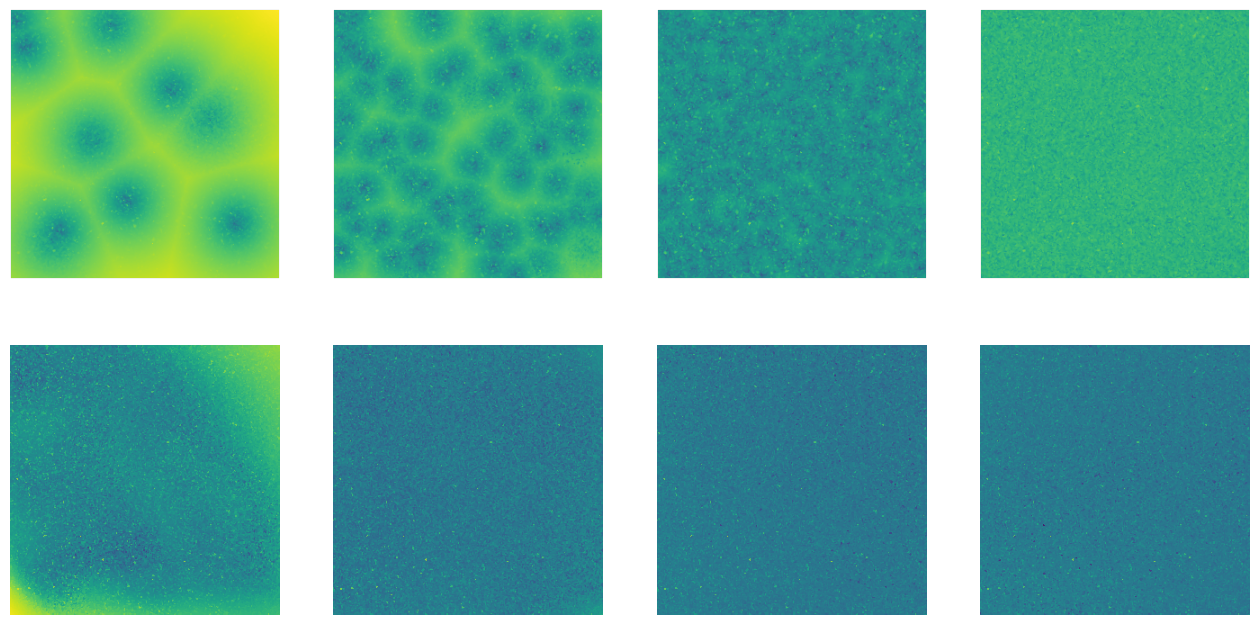

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Suppose you have:
# pts : (N, 2) array of 2D coordinates in [0, 5]^2
# z   : (N,) array of W2 values at those points
# e.g.
# pts = np.random.rand(1000, 2) * 5
# z = your_w2_values

fig, ax = plt.subplots(2, 4, figsize=(4 * 4, 4 * 2))

max_w2 = max([np.max(dist_w2s[n_unique_sets]) for n_unique_sets in [10, 100, 1000, 10_000]] + [np.max(emb_w2s[n_unique_sets]) for n_unique_sets in [10, 100, 1000, 10_000]])
min_w2 = min([np.min(dist_w2s[n_unique_sets]) for n_unique_sets in [10, 100, 1000, 10_000]] + [np.min(emb_w2s[n_unique_sets]) for n_unique_sets in [10, 100, 1000, 10_000]])

# create norm for max_w2
norm = LogNorm(vmin=min_w2, vmax=max_w2)

for i, n_unique_sets in enumerate([10, 100, 1000, 10_000]):

    target_mu = target_mus[n_unique_sets]
    dist_w2 = dist_w2s[n_unique_sets]
    emb_w2 = emb_w2s[n_unique_sets]

    # 1. Make a regular grid covering [0,5] × [0,5]
    grid_x, grid_y = np.meshgrid(
        np.linspace(0, 5, 300),
        np.linspace(0, 5, 300)
    )

    # 2. Interpolate your scattered data onto the grid
    grid_z_dist = griddata(
        points=target_mu,
        values=dist_w2,
        xi=(grid_x, grid_y),
        method='nearest'     # 'linear' and 'nearest' available
    )

    grid_z_emb = griddata(
        points=target_mu,
        values=emb_w2,
        xi=(grid_x, grid_y),
        method='linear'     # 'linear' and 'nearest' also available
    )

    # 3. Plot
    plt.figure(figsize=(6, 5))

    # Filled contours
    cs = ax[0, i].imshow(grid_z_emb, extent=[0,5,0,5], origin="lower", cmap="viridis", norm=norm)
    cs = ax[1, i].imshow(grid_z_dist, extent=[0,5,0,5], origin="lower", cmap="viridis", norm=norm)

    # for j in range(n_unique_sets):
    #     ax[0, i].scatter(ds.mu[j][0], ds.mu[j][1], color='red', alpha=1.0, s=8)
    #     ax[1, i].scatter(ds.mu[j][0], ds.mu[j][1], color='red', alpha=1.0, s=8)

for a in ax.ravel():
    a.set_aspect('equal')
    a.set_xticks([])
    a.set_yticks([])

# tight layout
plt.tight_layout()



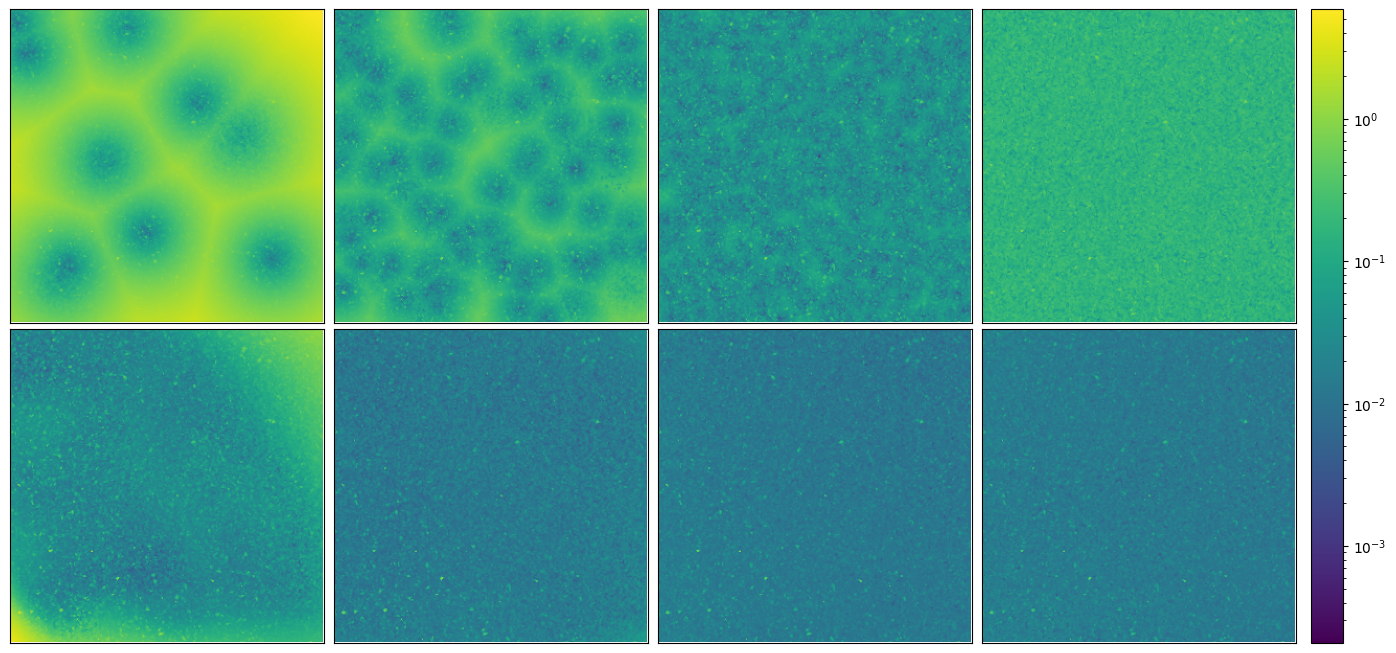

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.colors import LogNorm

fig, ax = plt.subplots(2, 4, figsize=(4 * 4, 4 * 1.65))

max_w2 = max([np.max(dist_w2s[n_unique_sets]) for n_unique_sets in [10, 100, 1000, 10_000]] +
             [np.max(emb_w2s[n_unique_sets])  for n_unique_sets in [10, 100, 1000, 10_000]])
min_w2 = min([np.min(dist_w2s[n_unique_sets]) for n_unique_sets in [10, 100, 1000, 10_000]] +
             [np.min(emb_w2s[n_unique_sets])  for n_unique_sets in [10, 100, 1000, 10_000]])

norm = LogNorm(vmin=min_w2, vmax=max_w2)

im = None  # will hold a handle for the colorbar

for i, n_unique_sets in enumerate([10, 100, 1000, 10_000]):

    target_mu = target_mus[n_unique_sets]
    dist_w2   = dist_w2s[n_unique_sets]
    emb_w2    = emb_w2s[n_unique_sets]

    grid_x, grid_y = np.meshgrid(
        np.linspace(0, 5, 300),
        np.linspace(0, 5, 300)
    )

    grid_z_dist = griddata(
        points=target_mu,
        values=dist_w2,
        xi=(grid_x, grid_y),
        method='linear'
    )

    grid_z_emb = griddata(
        points=target_mu,
        values=emb_w2,
        xi=(grid_x, grid_y),
        method='linear'
    )

    # plot (same as you had)
    im = ax[0, i].imshow(grid_z_emb, extent=[0, 5, 0, 5],
                         origin="lower", cmap="viridis", norm=norm)
    ax[1, i].imshow(grid_z_dist, extent=[0, 5, 0, 5],
                    origin="lower", cmap="viridis", norm=norm)

for a in ax.ravel():
    a.set_aspect('equal')
    a.set_xticks([])
    a.set_yticks([])

# tighten spacing between subplots
fig.subplots_adjust(left=0.02, right=0.98,
                    bottom=0.02, top=0.98,
                    wspace=0.02, hspace=0.02)

# shared colorbar
cbar = fig.colorbar(im, ax=ax.ravel().tolist(), pad=0.01, shrink=1.0)
# optional label:
# cbar.set_label(r"$W_2$ distance")

plt.show()
